In [26]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: /home/jovyan/work/motor-imagery-AI


In [27]:
from src.config import load_config
from src.data import (
    download_dataset, load_raw_subjects,
    epoch_subjects, epoch_with_params,
    EEGDataset, subject_split, make_dataloaders,
)
from src.models import EEGNet
from src.engine import train, eval_step, cross_validate_subjects, cv_for_preprocessing
from src.pipelines import (
    MultiClassCSP, run_csp_ml_grid,
    compute_mu_power, find_best_mu_threshold, two_stage_predict,
    run_eegnet_grid, run_preprocessing_grid, run_joint_grid,
    butter_bandpass_filter,
)
from src.utils import (
    set_seeds, get_device,
    plot_training_curves, plot_confusion_matrix, plot_model_comparison,
    print_evaluation, save_model, predict_with_model,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report

In [28]:
cfg = load_config()
set_seeds(cfg["seed"])
device = get_device()
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.11.0+cu128


In [29]:
subjects_data = download_dataset(
    cfg["data"]["dataset"],
    cfg["data"]["desired_runs"],
)

raw_data = load_raw_subjects(
    subjects_data,
    sfreq=cfg["data"]["sfreq"],
    n_subjects=cfg["data"].get("n_subjects"),
    cache_dir=cfg["data"].get("cache_dir"),
)

Dataset path: /home/jovyan/.cache/kagglehub/datasets/brianleung2020/eeg-motor-movementimagery-dataset/versions/1
Found 105 subjects (excluded 4 bad)


Loading subjects:  36%|███▌      | 38/105 [00:01<00:02, 30.15it/s]

⚠️ Subject 088: no valid files, skipping


Loading subjects:  70%|███████   | 74/105 [00:02<00:01, 30.41it/s]

⚠️ Subject 100: no valid files, skipping


Loading subjects:  93%|█████████▎| 98/105 [00:03<00:00, 30.26it/s]

⚠️ Subject 092: no valid files, skipping


Loading subjects: 100%|██████████| 105/105 [00:03<00:00, 29.48it/s]

Loaded 102 subjects


<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>
Channels: 64, Sfreq: 160.0 Hz
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



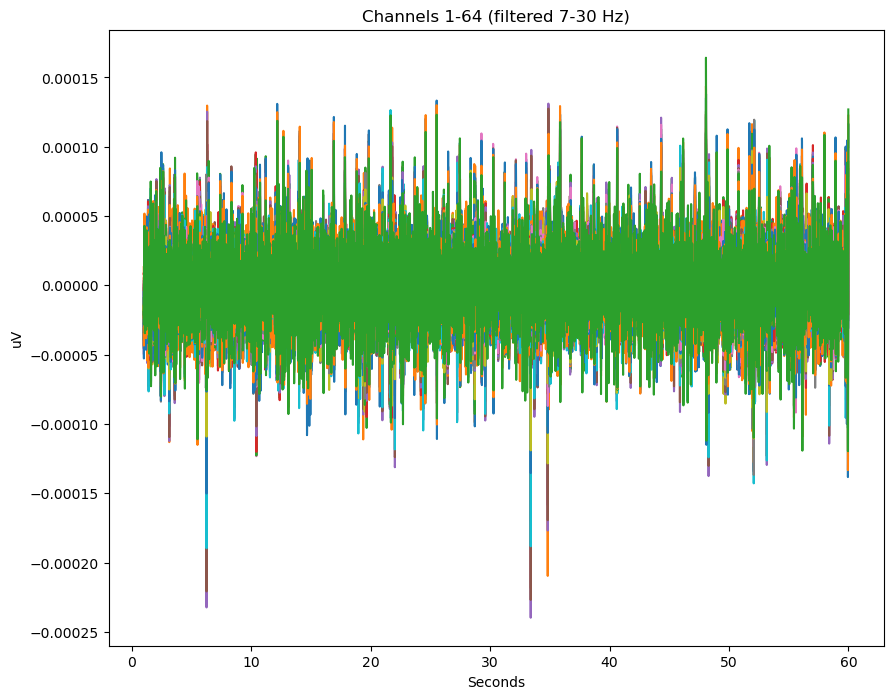

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


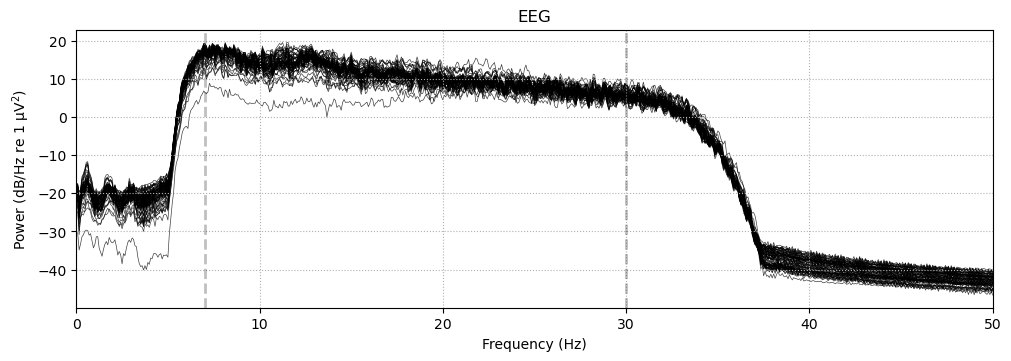

In [31]:
import mne

raw_obj = raw_data["001"]
print(raw_obj)
print(f"Channels: {len(raw_obj.ch_names)}, Sfreq: {raw_obj.info['sfreq']} Hz")

raw_copy = raw_obj.copy().filter(7., 30., fir_design="firwin", skip_by_annotation="edge")
sfreq = raw_copy.info["sfreq"]
data, times = raw_copy[:-1, int(sfreq * 1):int(sfreq * 60)]

fig = plt.subplots(figsize=(10, 8))
plt.plot(times, data.T)
plt.xlabel("Seconds"); plt.ylabel("uV")
plt.title("Channels 1-64 (filtered 7-30 Hz)")
plt.show()

raw_copy.compute_psd(fmax=50).plot()
plt.show()

In [34]:
X_all, y_all, subjects_all, skipped = epoch_subjects(
    raw_data,
    event_id={"left_hand": 2, "right_hand": 3},
    channels=None,
    low_freq=0.5,
    high_freq=79.0,
    tmin=0.0,
    tmax=4.0,
    label_offset=2,
    seed=cfg["seed"],
)

In [ ]:
split = subject_split(X_all, y_all, subjects_all, seed=cfg["seed"])s
loaders = make_dataloaders(split, batch_size=64)
cv_mask = split["train_mask"] | split["val_mask"]

eeg_net = EEGNet(chans=21, classes=2, time_points=X_all.shape[2]).to(device)
w = compute_class_weight("balanced", classes=np.unique(split["y_train"]), y=split["y_train"])
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))
opt = torch.optim.Adam(eeg_net.parameters(), lr=0.001)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=100)
results, _ = train(eeg_net, loaders["train_loader"], loaders["val_loader"],
                   loaders["test_loader"], opt, loss_fn, sched, device, epochs=100)
plot_training_curves(results, "Binary L/R")
preds, labels = predict_with_model(eeg_net, loaders["test_loader"], device)
print_evaluation(labels, preds, ["left_hand", "right_hand"])
plot_confusion_matrix(labels, preds, ["left_hand", "right_hand"])

In [35]:
class MIModel(nn.Module):
    def __init__(self):
        pass